<a href="https://colab.research.google.com/github/KANGWEII/hands_on_ml/blob/feature-chapter_6/Chapter06/decision_trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 6: Decision Trees

Machine learning algorithms that can perform both classification and regression tasks, and even multioutput tasks

## Training and Visualizing a Decision Tree

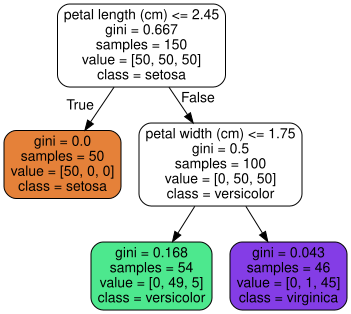

In [1]:
# Train DecisionTreeClassifier on the iris dataset

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

# Visualize the trained decision tree

from sklearn.tree import export_graphviz

export_graphviz(
    tree_clf,
    out_file="iris_tree.dot",
    feature_names=iris.feature_names[2:],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

from graphviz import Source

Source.from_file("iris_tree.dot")

- gini: measures *Gini impurity*
- If a node is "pure", gini=0, when all training instances belong to the same class
- For class=versicolor node
$$
1 - (\frac{0}{54})^2 - (\frac{49}{54})^2 - (\frac{5}{54})^2 = 0.168
$$
- Gini Impurity
$$
G_i = 1 - \sum_{k=1}^n p_{i,k}^2
$$
  where
  - $G_i$ is the Gini impurity of the $i^{th}$ node
  - $P_{i,k}$ is the ratio of class $k$ instances among the training instances in the $i^{th}$ node

- Scikit-Learn uses the CART algorithm, which produces only binary trees, only two children nodes (yes or no answers)
- Other algorithms such as ID3 can produce children nodes with more than two children

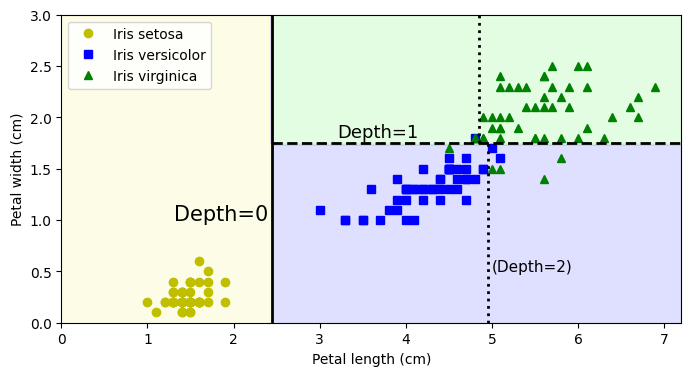

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])
plt.figure(figsize=(8, 4))

lengths, widths = np.meshgrid(np.linspace(0, 7.2, 100), np.linspace(0, 3, 100))
X_iris_all = np.c_[lengths.ravel(), widths.ravel()]
y_pred = tree_clf.predict(X_iris_all).reshape(lengths.shape)
plt.contourf(lengths, widths, y_pred, alpha=0.3, cmap=custom_cmap)
for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(X_iris[:, 0][y_iris == idx], X_iris[:, 1][y_iris == idx],
             style, label=f"Iris {name}")

tree_clf_deeper = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf_deeper.fit(X_iris, y_iris)
th0, th1, th2a, th2b = tree_clf_deeper.tree_.threshold[[0, 2, 3, 6]]
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.plot([th0, th0], [0, 3], "k-", linewidth=2)
plt.plot([th0, 7.2], [th1, th1], "k--", linewidth=2)
plt.plot([th2a, th2a], [0, th1], "k:", linewidth=2)
plt.plot([th2b, th2b], [th1, 3], "k:", linewidth=2)
plt.text(th0 - 0.05, 1.0, "Depth=0", horizontalalignment="right", fontsize=15)
plt.text(3.2, th1 + 0.02, "Depth=1", verticalalignment="bottom", fontsize=13)
plt.text(th2a + 0.05, 0.5, "(Depth=2)", fontsize=11)
plt.axis([0, 7.2, 0, 3])
plt.legend()

plt.show()

- If set max_depth to 3, two vertical dotted lines represent the decision boundary

## Estimating Class Probabilities

- 0% for Iris setosa (0/54)
- 90.7% for Iris versicolor (49/54)
- 9.3% for Iris virginica (5/54)

Output will be the class with the highest probability

In [3]:
tree_clf.predict_proba([[5, 1.5]]).round(3)

array([[0.   , 0.907, 0.093]])

In [4]:
tree_clf.predict([[5, 1.5]])

array([1])

## The CART Training Algorithm

- Classification and Regression Tree (CART)
- The algorithm works by first splitting the training set into two subsets using a single feature $k$ and a threshold $t_k$ (eg. petal length $\le$ 2.45cm)
- It searches for the pair ($k$, $t_k$) that produces the purest subsets
- CART cost function for classification
$$
J(k, t_k) = \frac{m_{left}}{m}G_{left} + \frac{m_{right}}{m}G_{right}
$$
  where:
  - $G_{left/right}$ measures the impurity of the left/right subset
  - $m_{left/right}$ is the number of instances in the left/right subset
- Once the training set is split in two, it splits the subsets using the same logic, then the sub-subsets, and so on until it reaches the depth defined by the **max_depth** hyperparameter
- Additional hyperparameters to control stopping condition:
  - min_samples_split
  - min_samples_leaf
  - min_weight_fraction_leaf
  - max_leaf_nodes

## Computational Complexity

- Traversing the decision tree requires going through roughly $O(log_2(m)$ nodes, where $log_2(m)$ is the binary logarithm of $m$
- Prediction complexity is independent of the number of features

## Gini Impurity or Entropy?

- *DecisionTreeClassifier* class uses the Gini impurity measure by default
- Setting the *criterion* hyperparameter to "entropy" to select the *entropy* impurity
- A set's entropy is zero when it contains instances of only one class
- Entropy equation
$$
H_i = -\sum_{k=1}^{n} P_{i,k} log_2(P_{i,k})
$$
- Refer to the decision tree above for the node with class = versicolor
$$
\begin{aligned}
Entropy &= -\frac{49}{54}log_2(\frac{49}{54}) - \frac{5}{54}log_(\frac{5}{54}) \\
&= 0.445
\end{aligned}
$$

- Gini impurity and entropy lead to the same trees
- Gini is slightly faster, a good default
- Gini tends to isolate the most frequent class in its own brnach of the tree
- Entropy tends to produce slightly more balanced trees

## Regularization Hyperparameters

- To avoid overfitting, restrict the decision tree's freedom during training (regularization)
- max_depth
  - restrict the maximum depth of the decision tree
  - default is none
- max_features
  - maximum number of features that are evaluated for splitting at each node
- max_leaf_nodes
  - maximum number of leaf nodes
- min_samples_split
  - minimum number of samples a node must have before it can be split
- min_samples_leaf
  - minimum number of samples of leaf node must have to be created
- min_weight_fraction_leaf
  - same as *min_samples_leaf* but expressed as a fracction of the total number of weighted instances
- Increasing min_* hyperparameters or reducing max_* hyperparameters will regularize the model

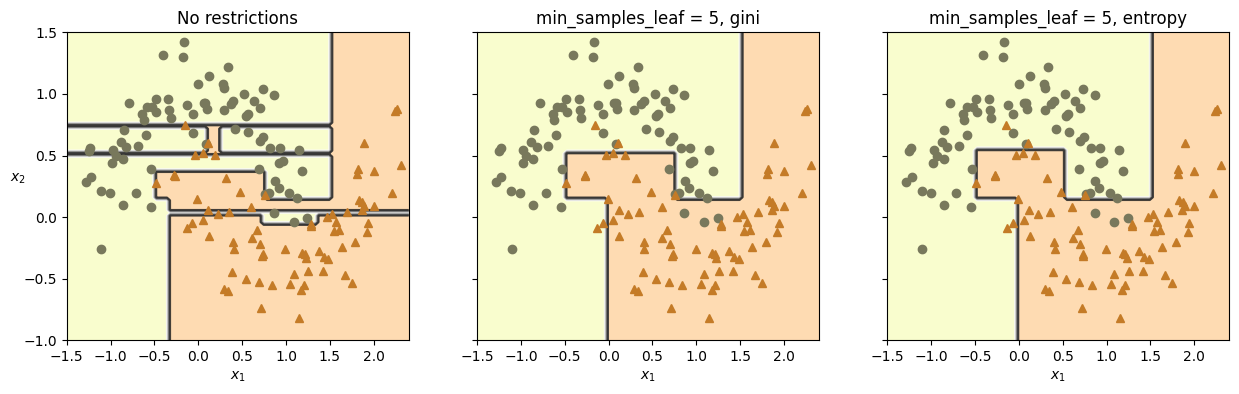

In [24]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=150, noise=0.2, random_state=42)

tree_clf1 = DecisionTreeClassifier(random_state=42)
tree_clf2 = DecisionTreeClassifier(min_samples_leaf=5, random_state=42)
tree_clf3 = DecisionTreeClassifier(criterion="entropy", min_samples_leaf=5, random_state=42)

tree_clf1.fit(X_moons, y_moons)
tree_clf2.fit(X_moons, y_moons)
tree_clf3.fit(X_moons, y_moons)

# Plot
def plot_decision_boundary(clf, X, y, axes, cmap):
    x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                         np.linspace(axes[2], axes[3], 100))
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=cmap)
    plt.contour(x1, x2, y_pred, cmap="Greys", alpha=0.8)
    colors = {"Wistia": ["#78785c", "#c47b27"], "Pastel1": ["red", "blue"]}
    markers = ("o", "^")
    for idx in (0, 1):
        plt.plot(X[:, 0][y == idx], X[:, 1][y == idx],
                 color=colors[cmap][idx], marker=markers[idx], linestyle="none")
    plt.axis(axes)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation=0)

fig, axes = plt.subplots(ncols=3, figsize=(15, 4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf1, X_moons, y_moons, axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title("No restrictions")
plt.sca(axes[1])
plot_decision_boundary(tree_clf2, X_moons, y_moons, axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title(f"min_samples_leaf = {tree_clf2.min_samples_leaf}, {tree_clf2.criterion}")
plt.ylabel("")
plt.sca(axes[2])
plot_decision_boundary(tree_clf3, X_moons, y_moons, axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title(f"min_samples_leaf = {tree_clf3.min_samples_leaf}, {tree_clf3.criterion}")
plt.ylabel("")

plt.show()

- Left plot is unregularized (overfitting)
- Right plot is regularized, it will generalize better

In [6]:
# Verify
X_moons_test, y_moons_test = make_moons(n_samples=1000, noise=0.2, random_state=43)

In [7]:
tree_clf1.score(X_moons_test, y_moons_test)

0.898

In [22]:
# Verify that the regularized tree has a better accuracy on the test set
tree_clf2.score(X_moons_test, y_moons_test)

0.92

In [23]:
# Score for entropy impurity
tree_clf3.score(X_moons_test, y_moons_test)

0.933